## Ai Ford Car Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## EDA


In [2]:
df=pd.read_csv("ford.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [3]:
df.shape
df.size
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [4]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


<Axes: xlabel='year', ylabel='price'>

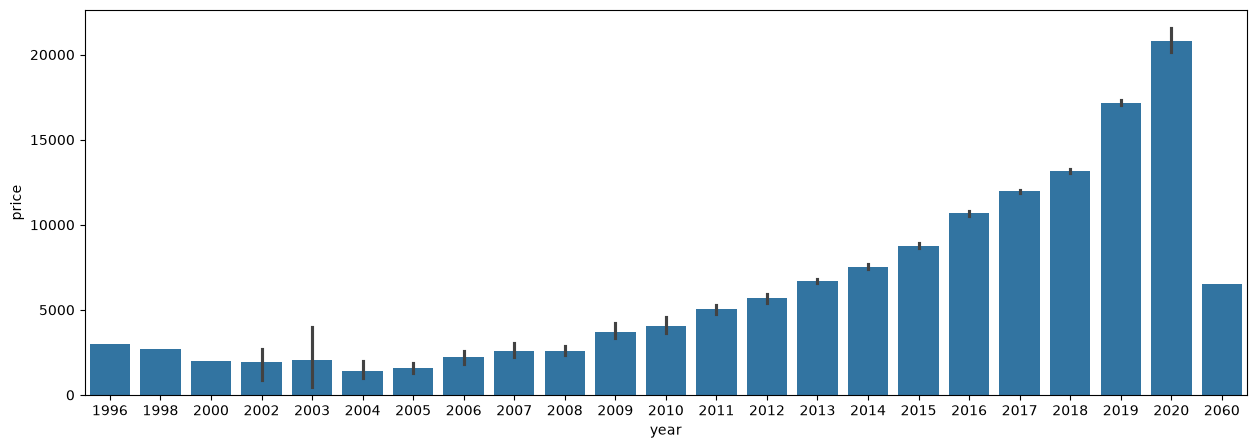

In [5]:
plt.figure(figsize=(15,5))
sns.barplot(x="year",y="price",data=df)

<Axes: xlabel='year', ylabel='price'>

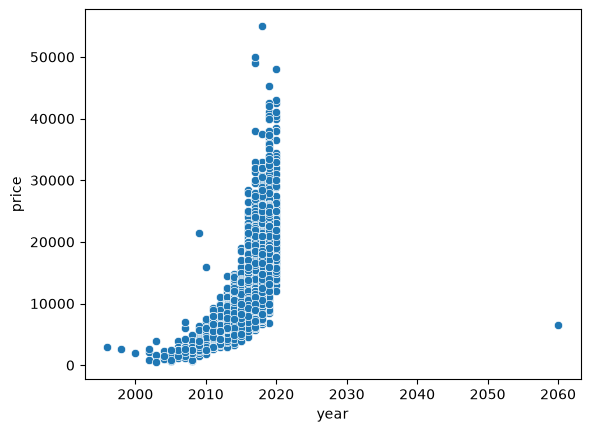

In [6]:
sns.scatterplot(x="year",y="price",data=df)

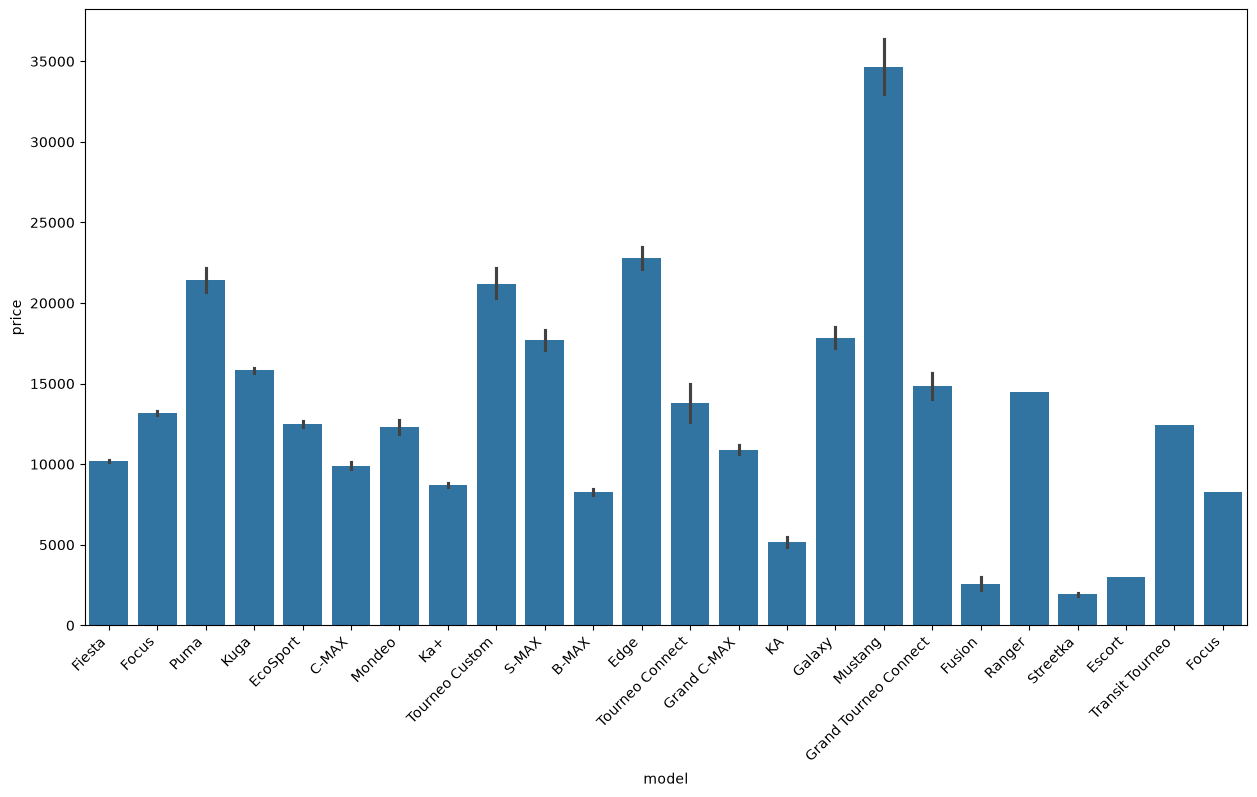

In [7]:
plt.figure(figsize=(15,8))
fig=sns.barplot(x="model",y="price",data=df)
plt.xticks(rotation=45, horizontalalignment='right') 
plt.show()

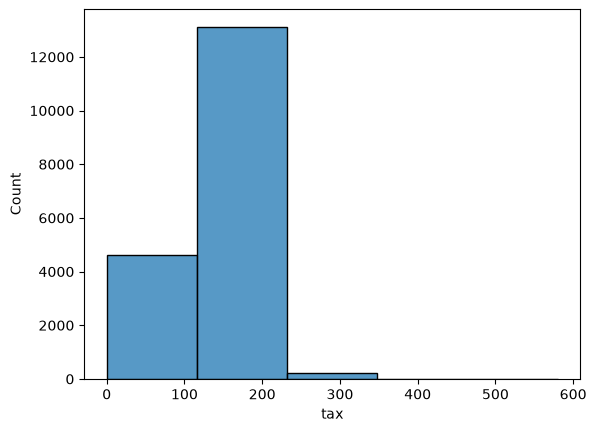

In [8]:
sns.histplot(x="tax",data=df,bins=5)
plt.show()

<Axes: xlabel='fuelType', ylabel='price'>

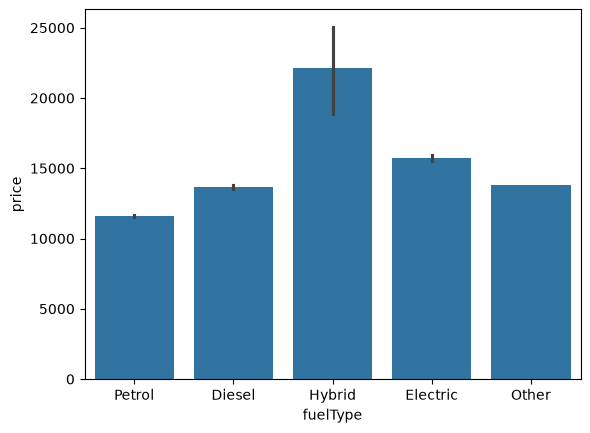

In [9]:
sns.barplot(x="fuelType",y="price",data=df)

<Axes: xlabel='fuelType', ylabel='price'>

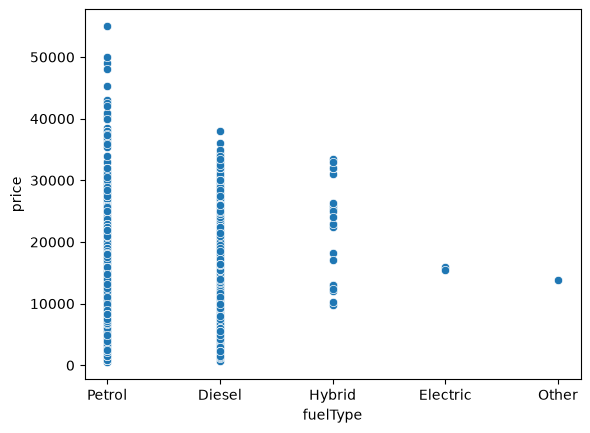

In [10]:
sns.scatterplot(x="fuelType",y="price",data=df)

<Axes: >

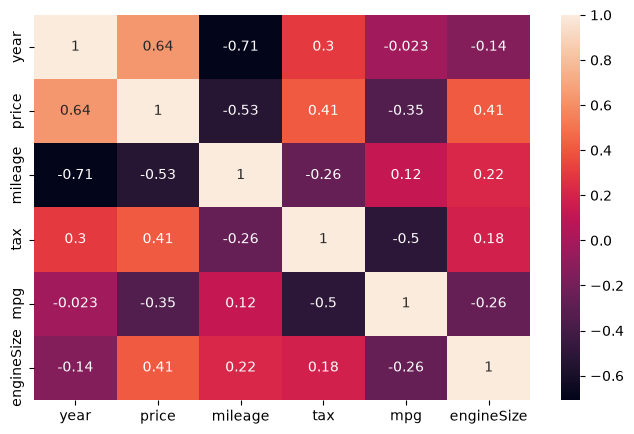

In [11]:
plt.figure(figsize=(8,5))
cor=df.corr(numeric_only=True)
sns.heatmap(cor,annot=True)

In [12]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='str')

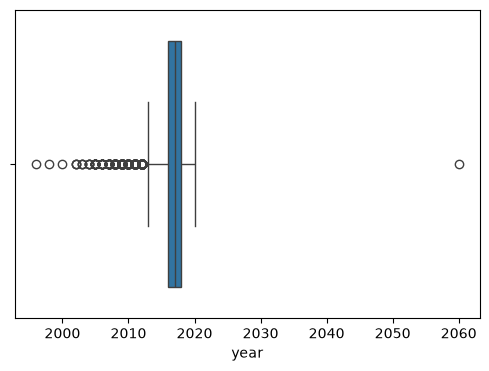

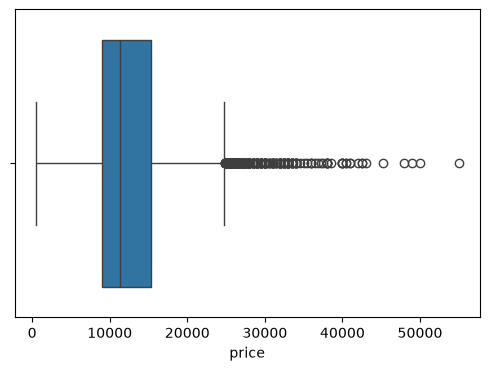

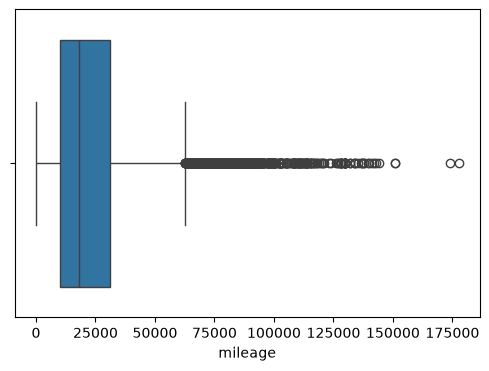

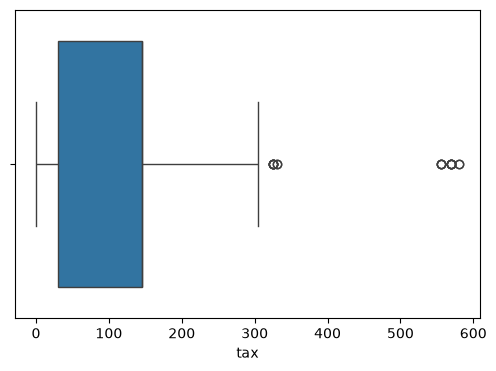

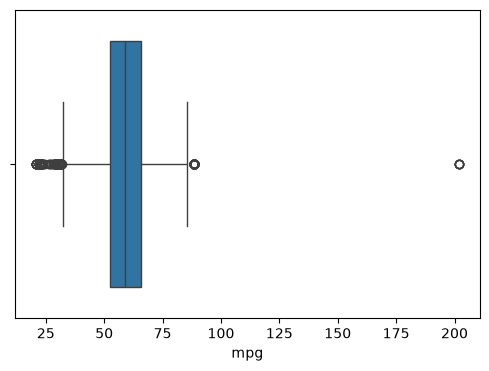

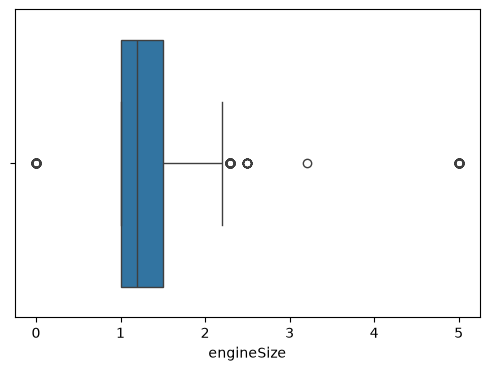

In [13]:
numeric_columns = ['year', 'price', 'mileage','tax',
       'mpg', 'engineSize' ]
for col in numeric_columns:
    plt.figure(figsize= (6,4))
    sns.boxplot(x = df[col])

<Axes: xlabel='mileage', ylabel='price'>

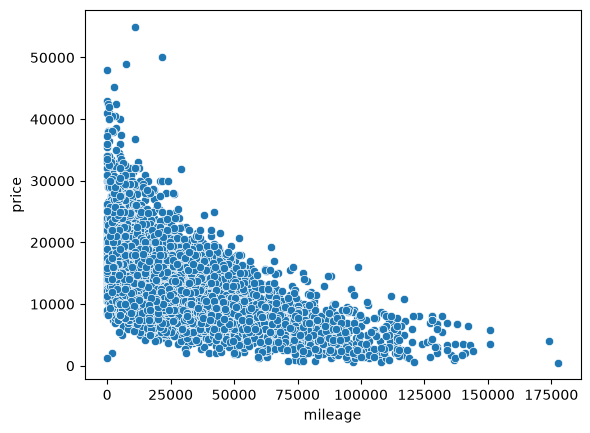

In [14]:
sns.scatterplot(x="mileage",y="price",data=df)

## Data Processing and Feature Extraction

In [15]:
df_clean = df.copy()

df_clean = pd.get_dummies(
    df_clean,
    columns=["fuelType"],
    drop_first=True
)

df_clean.head()

,model,year,price,transmission,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,Fiesta,2017,12000,Automatic,15944,150,57.7,1.0,False,False,False,True
1,Focus,2018,14000,Manual,9083,150,57.7,1.0,False,False,False,True
2,Focus,2017,13000,Manual,12456,150,57.7,1.0,False,False,False,True
3,Fiesta,2019,17500,Manual,10460,145,40.3,1.5,False,False,False,True
4,Fiesta,2019,16500,Automatic,1482,145,48.7,1.0,False,False,False,True


In [16]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["model"],
    drop_first=True
)

df_clean.head()

,year,price,transmission,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,...,model_ Mondeo,model_ Mustang,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus
0,2017,12000,Automatic,15944,150,57.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2018,14000,Manual,9083,150,57.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2017,13000,Manual,12456,150,57.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2019,17500,Manual,10460,145,40.3,1.5,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2019,16500,Automatic,1482,145,48.7,1.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["transmission"],
    drop_first=True
)

df_clean.head()

,year,price,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto
0,2017,12000,15944,150,57.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,2018,14000,9083,150,57.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,2017,13000,12456,150,57.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,2019,17500,10460,145,40.3,1.5,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,2019,16500,1482,145,48.7,1.0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [18]:
df_clean=df_clean.astype(int)
df_clean

,year,price,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto
0,2017,12000,15944,150,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2018,14000,9083,150,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2017,13000,12456,150,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,2019,17500,10460,145,40,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,2019,16500,1482,145,48,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,2017,8999,16700,150,47,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
17962,2014,7499,40700,30,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
17963,2015,9999,7010,20,67,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17964,2018,8299,5007,145,57,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


<Axes: >

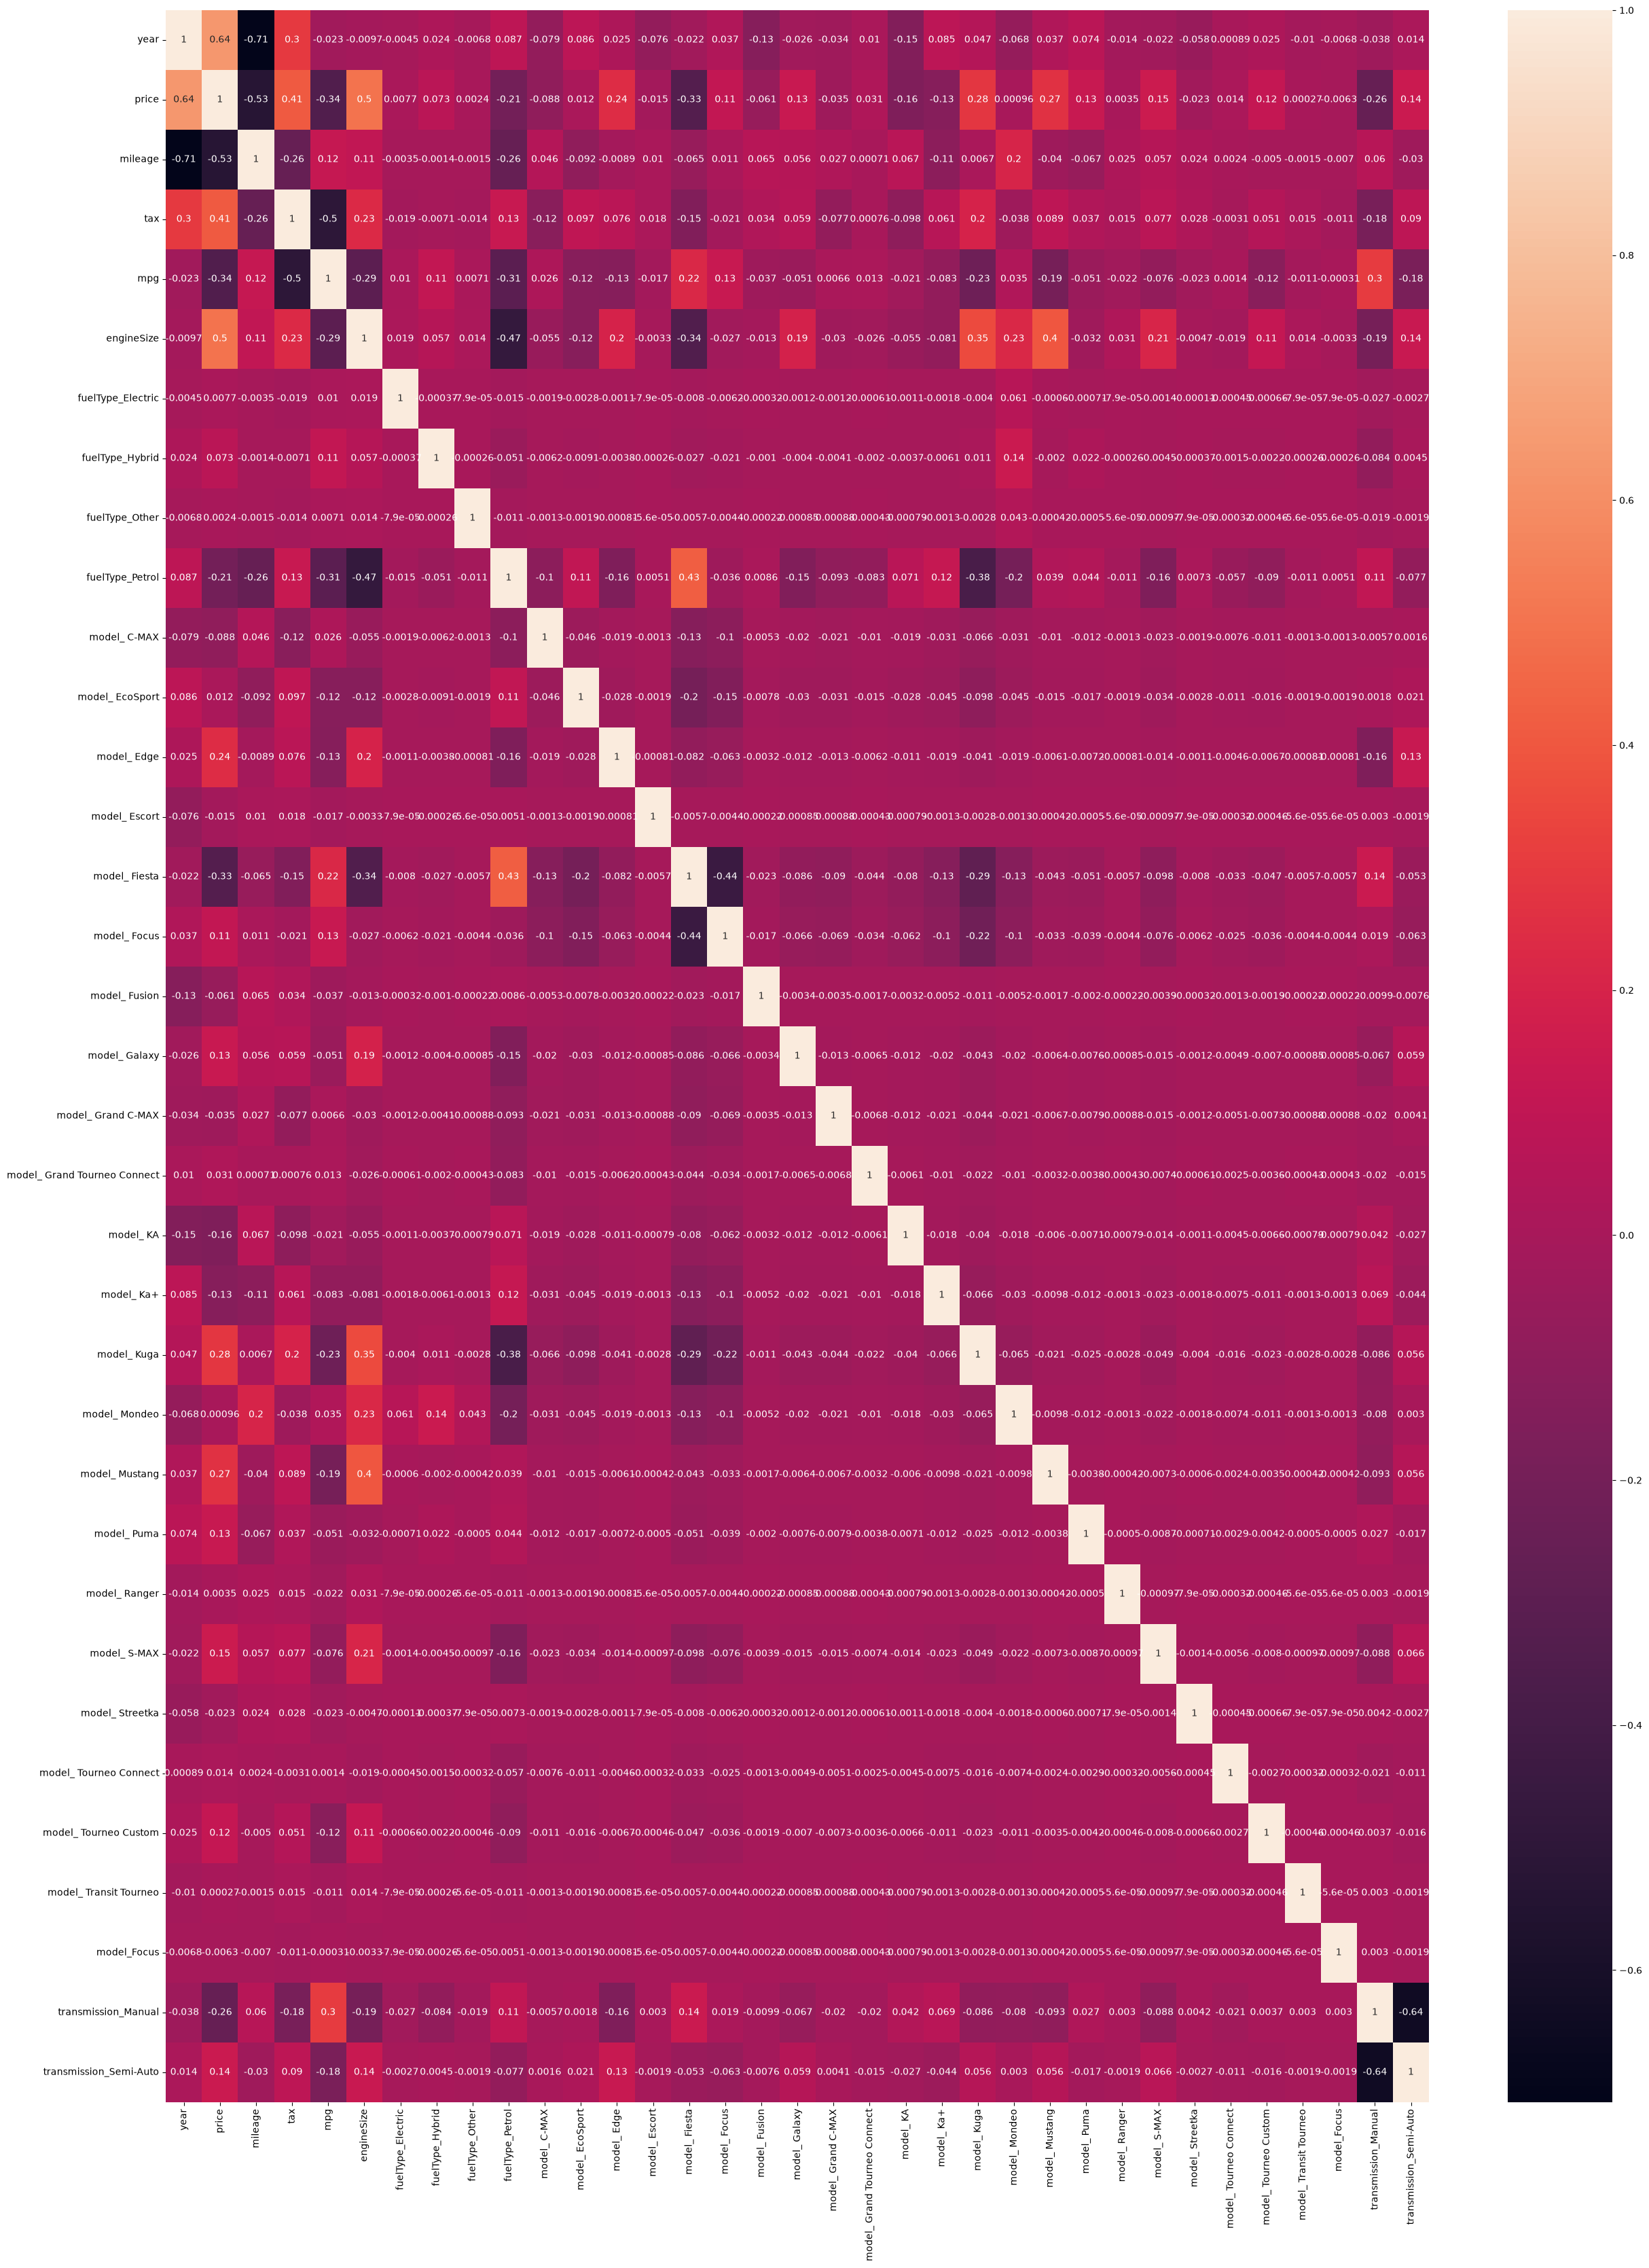

In [19]:
plt.figure(figsize=(30,40))
cor=df_clean.corr(numeric_only=True)
sns.heatmap(cor,annot=True)

## Train Data In Model

In [20]:
from sklearn.preprocessing import StandardScaler
col=["year","mileage","tax","mpg","engineSize"]

scaler=StandardScaler()
df_clean[col]=scaler.fit_transform(df_clean[col])
df_clean

,year,price,mileage,tax,mpg,engineSize,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,...,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto
0,0.065128,12000,-0.380998,0.591358,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0.552866,14000,-0.733359,0.591358,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0.065128,13000,-0.560132,0.591358,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
3,1.040605,17500,-0.662640,0.510727,-1.721198,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
4,1.040605,16500,-1.123724,0.510727,-0.931045,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,8999,-0.342172,0.591358,-1.029814,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
17962,-1.398088,7499,0.890398,-1.343791,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
17963,-0.910349,9999,-0.839822,-1.505053,0.945569,-0.447984,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17964,0.552866,8299,-0.942690,0.510727,-0.042122,-0.447984,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0


In [21]:
df_clean.columns[df_clean.columns.duplicated()] #no dublicate col
df_clean.columns

Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol', 'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto'],
      dtype='str')

In [22]:
from scipy.stats import pearsonr

selected_features = [
 'year', 'mileage', 'tax', 'mpg', 'engineSize',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol', 'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto'
]


correlations = {
    feature: pearsonr(df_clean[feature], df_clean['price'])[0]
    for feature in selected_features
}# comprension dict

correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)
correlation_df.sort_values(by="Pearson Correlation",ascending=False)


,Feature,Pearson Correlation
0,year,0.636009
4,engineSize,0.495327
2,tax,0.406857
21,model_ Kuga,0.281025
23,model_ Mustang,0.265964
11,model_ Edge,0.240388
26,model_ S-MAX,0.148523
33,transmission_Semi-Auto,0.141278
16,model_ Galaxy,0.133010
24,model_ Puma,0.129318


In [23]:
cat_features={
       'year','mileage', 'tax', 'mpg', 'engineSize',
       'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other',
       'fuelType_Petrol', 'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus', 'transmission_Manual',
       'transmission_Semi-Auto'
}

from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

# Create a copy only for Chi-Square
chi_df = df_clean.copy()

# Convert price into categories only in the copy
chi_df['prices'] = pd.qcut(chi_df['price'], q=4, labels=False)

chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(chi_df[col], chi_df['prices'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)

    chi2_results[col] = {
        "chi2_statistic": chi2_stat,
        "p_value": p_val,
        "Decision": "Reject Null (Keep Feature)" if p_val < alpha else "Accept Null (Drop Feature)"
    }

chi2_df = (
    pd.DataFrame(chi2_results)
    .T
    .sort_values("p_value")
)

chi2_df

,chi2_statistic,p_value,Decision
mpg,9005.001679,0.0,Reject Null (Keep Feature)
tax,6276.358489,0.0,Reject Null (Keep Feature)
model_ Kuga,1815.281036,0.0,Reject Null (Keep Feature)
engineSize,3566.314279,0.0,Reject Null (Keep Feature)
year,12153.089936,0.0,Reject Null (Keep Feature)
model_ Fiesta,2446.046072,0.0,Reject Null (Keep Feature)
transmission_Manual,931.764446,0.0,Reject Null (Keep Feature)
fuelType_Petrol,827.675386,0.0,Reject Null (Keep Feature)
model_ Edge,618.691706,0.0,Reject Null (Keep Feature)
model_ Ka+,593.868402,0.0,Reject Null (Keep Feature)


In [24]:
final_df=df_clean[["year","tax","engineSize","mpg","price","mileage","transmission_Semi-Auto","fuelType_Hybrid",'model_ C-MAX', 'model_ EcoSport', 'model_ Edge',
       'model_ Escort', 'model_ Fiesta', 'model_ Focus', 'model_ Fusion',
       'model_ Galaxy', 'model_ Grand C-MAX', 'model_ Grand Tourneo Connect',
       'model_ KA', 'model_ Ka+', 'model_ Kuga', 'model_ Mondeo',
       'model_ Mustang', 'model_ Puma', 'model_ Ranger', 'model_ S-MAX',
       'model_ Streetka', 'model_ Tourneo Connect', 'model_ Tourneo Custom',
       'model_ Transit Tourneo', 'model_Focus',"transmission_Manual","fuelType_Electric"]]
final_df

,year,tax,engineSize,mpg,price,mileage,transmission_Semi-Auto,fuelType_Hybrid,model_ C-MAX,model_ EcoSport,...,model_ Puma,model_ Ranger,model_ S-MAX,model_ Streetka,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,fuelType_Electric
0,0.065128,0.591358,-0.447984,-0.042122,12000,-0.380998,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.552866,0.591358,-0.447984,-0.042122,14000,-0.733359,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0.065128,0.591358,-0.447984,-0.042122,13000,-0.560132,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1.040605,0.510727,-0.447984,-1.721198,17500,-0.662640,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1.040605,0.510727,-0.447984,-0.931045,16500,-1.123724,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17961,0.065128,0.591358,-0.447984,-1.029814,8999,-0.342172,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17962,-1.398088,-1.343791,-0.447984,-0.042122,7499,0.890398,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17963,-0.910349,-1.505053,-0.447984,0.945569,9999,-0.839822,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
17964,0.552866,0.510727,-0.447984,-0.042122,8299,-0.942690,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [25]:
from sklearn.model_selection import train_test_split


In [26]:
X=final_df.drop("price",axis=1)# here axis 1 means drop col charges 0 means row
y=final_df["price"]
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
model=LinearRegression()
model.fit(X_test,y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[1924.54, -14.99, 989.91,..., 0. ,-656.4 , 772.88]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['year','tax','engineSize',...,'model_Focus','transmission_Manual', 'fuelType_Electric']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.053e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(28)


In [29]:
y_pred=model.predict(X_test)
y_pred

array([ 7225.7399394 ,  9530.81351439,  8856.03290088, ...,
       23165.10920901,  9955.14543116, 15009.66139269], shape=(3594,))

## Model Accuracy

In [30]:
from sklearn.metrics import r2_score

r2=r2_score(y_test,y_pred)
r2

0.8496778275577445

In [31]:
n=X_test.shape[0]
p=X_test.shape[1]
adj_r2=1-((1-r2)*(n-1)/(n-p-1))
adj_r2

0.8483269964658736

## Model Testing 

In [32]:

# New sample
test_data = pd.DataFrame([{
    "year": 2021,
    "tax": 155,
    "engineSize": 2.0,
    "mpg": 54.3,
    "mileage": 12000,

    "transmission_Semi-Auto": 1,
    "transmission_Manual": 0,

    "fuelType_Hybrid": 1,
    "fuelType_Electric": 0,

    "model_ C-MAX": 0,
    "model_ EcoSport": 0,
    "model_ Edge": 0,
    "model_ Escort": 0,
    "model_ Fiesta": 0,
    "model_ Focus": 0,
    "model_ Fusion": 0,
    "model_ Galaxy": 0,
    "model_ Grand C-MAX": 0,
    "model_ Grand Tourneo Connect": 0,
    "model_ KA": 0,
    "model_ Ka+": 0,
    "model_ Kuga": 1,
    "model_ Mondeo": 0,
    "model_ Mustang": 0,
    "model_ Puma": 0,
    "model_ Ranger": 0,
    "model_ S-MAX": 0,
    "model_ Streetka": 0,
    "model_ Tourneo Connect": 0,
    "model_ Tourneo Custom": 0,
    "model_ Transit Tourneo": 0,
    "model_Focus": 0
}])

feature_cols = [
    "year","tax","engineSize","mpg","mileage",
    "transmission_Semi-Auto","fuelType_Hybrid",
    "model_ C-MAX","model_ EcoSport","model_ Edge",
    "model_ Escort","model_ Fiesta","model_ Focus",
    "model_ Fusion","model_ Galaxy",
    "model_ Grand C-MAX","model_ Grand Tourneo Connect",
    "model_ KA","model_ Ka+","model_ Kuga",
    "model_ Mondeo","model_ Mustang","model_ Puma",
    "model_ Ranger","model_ S-MAX","model_ Streetka",
    "model_ Tourneo Connect","model_ Tourneo Custom",
    "model_ Transit Tourneo","model_Focus",
    "transmission_Manual","fuelType_Electric"
]

num_cols = ["year", "mileage", "tax", "mpg", "engineSize"]

# Scale ONLY the numeric columns
test_data[num_cols] = scaler.transform(test_data[num_cols])#From test_data, select the columns whose names are in num_cols.

# Predict
prediction = model.predict(test_data[feature_cols])#From test_data, select the columns whose names are in feature_cols.

print("Car Price is :", round(prediction[0], 2),"$")

Car Price is : 23468.38 $


In [33]:
test_data = pd.DataFrame([{
    "year": 2024,
    "tax": 190,
    "engineSize": 5.0,
    "mpg": 18,
    "mileage": 5000,

    "transmission_Semi-Auto": 0,
    "transmission_Manual": 1,

    "fuelType_Hybrid": 0,
    "fuelType_Electric": 0,

    "model_ C-MAX": 0,
    "model_ EcoSport": 0,
    "model_ Edge": 0,
    "model_ Escort": 0,
    "model_ Fiesta": 0,
    "model_ Focus": 0,
    "model_ Fusion": 0,
    "model_ Galaxy": 0,
    "model_ Grand C-MAX": 0,
    "model_ Grand Tourneo Connect": 0,
    "model_ KA": 0,
    "model_ Ka+": 0,
    "model_ Kuga": 0,
    "model_ Mondeo": 0,
    "model_ Mustang": 1,
    "model_ Puma": 0,
    "model_ Ranger": 0,
    "model_ S-MAX": 0,
    "model_ Streetka": 0,
    "model_ Tourneo Connect": 0,
    "model_ Tourneo Custom": 0,
    "model_ Transit Tourneo": 0,
    "model_Focus": 0
}])

num_cols = ["year", "mileage", "tax", "mpg", "engineSize"]

# Scale ONLY the numeric columns
test_data[num_cols] = scaler.transform(test_data[num_cols])#From test_data, select the columns whose names are in num_cols.

# Predict
prediction = model.predict(test_data[feature_cols])#From test_data, select the columns whose names are in feature_cols.

print("Car Price is :", round(prediction[0], 2),"$")

Car Price is : 42804.6 $


In [34]:
test_data = pd.DataFrame([{
    "year": 2017,
    "tax": 150,
    "engineSize": 1.0,
    "mpg": 57.7,
    "mileage": 15944,

    "transmission_Semi-Auto": 0,
    "transmission_Manual": 0,   # Automatic

    "fuelType_Hybrid": 0,
    "fuelType_Electric": 0,     # Petrol

    "model_ C-MAX": 0,
    "model_ EcoSport": 0,
    "model_ Edge": 0,
    "model_ Escort": 0,
    "model_ Fiesta": 1,
    "model_ Focus": 0,
    "model_ Fusion": 0,
    "model_ Galaxy": 0,
    "model_ Grand C-MAX": 0,
    "model_ Grand Tourneo Connect": 0,
    "model_ KA": 0,
    "model_ Ka+": 0,
    "model_ Kuga": 0,
    "model_ Mondeo": 0,
    "model_ Mustang": 0,
    "model_ Puma": 0,
    "model_ Ranger": 0,
    "model_ S-MAX": 0,
    "model_ Streetka": 0,
    "model_ Tourneo Connect": 0,
    "model_ Tourneo Custom": 0,
    "model_ Transit Tourneo": 0,
    "model_Focus": 0
}])

num_cols = ["year","mileage","tax","mpg","engineSize"]

test_data[num_cols] = scaler.transform(test_data[num_cols])

prediction = model.predict(test_data[feature_cols])

print("Actual Price    :", 12000)
print("Predicted Price :", round(prediction[0],2))
print("Error           :", round(abs(12000-prediction[0]),2))

Actual Price    : 12000
Predicted Price : 11598.09
Error           : 401.91


In [35]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R²: 0.8496778275577445
MAE: 1370.0567682978547
RMSE: 1835.491295924914


In [36]:
def predict_car(model_name, year, actual_price, transmission,
                mileage, fuel, tax, mpg, engine_size):

    # Create a row with all features initialized to 0
    test_data = pd.DataFrame(0, index=[0], columns=feature_cols)

    # Numeric features
    test_data["year"] = year
    test_data["tax"] = tax
    test_data["engineSize"] = engine_size
    test_data["mpg"] = mpg
    test_data["mileage"] = mileage

    # Transmission
    if transmission == "Manual":
        test_data["transmission_Manual"] = 1
    elif transmission == "Semi-Auto":
        test_data["transmission_Semi-Auto"] = 1
    # Automatic is the reference category (both dummy columns remain 0)

    # Fuel
    if fuel == "Hybrid":
        test_data["fuelType_Hybrid"] = 1
    elif fuel == "Electric":
        test_data["fuelType_Electric"] = 1
    # Petrol/Diesel are the reference categories

    # Model
    col = f"model_ {model_name}"
    if col in test_data.columns:
        test_data[col] = 1

    col = f"model_{model_name}"
    if col in test_data.columns:
        test_data[col] = 1

    # Scale numeric columns
    num_cols = ["year", "mileage", "tax", "mpg", "engineSize"]
    test_data[num_cols] = scaler.transform(test_data[num_cols])

    # Predict
    pred = model.predict(test_data[feature_cols])[0]

    print(f"{model_name:10} | Actual: ${actual_price:7,.0f} | "
          f"Predicted: ${pred:8.2f} | "
          f"Error: ${abs(actual_price-pred):7.2f}")
    
predict_car("Focus", 2018, 14000, "Manual", 9083, "Petrol", 150, 57.7, 1.0)

predict_car("Focus", 2017, 13000, "Manual", 12456, "Petrol", 150, 57.7, 1.0)

predict_car("Fiesta", 2019, 17500, "Manual", 10460, "Petrol", 145, 40.3, 1.5)

predict_car("Fiesta", 2019, 16500, "Automatic", 1482, "Petrol", 145, 48.7, 1.0)

predict_car("Fiesta", 2015, 10500, "Manual", 35432, "Petrol", 145, 47.9, 1.6)

predict_car("Puma", 2019, 22500, "Manual", 2029, "Petrol", 145, 50.4, 1.0)

predict_car("Fiesta", 2017, 9000, "Manual", 13054, "Petrol", 145, 54.3, 1.2)

predict_car("Kuga", 2019, 25500, "Automatic", 6894, "Diesel", 145, 42.2, 2.0)

predict_car("Focus", 2018, 10000, "Manual", 48141, "Petrol", 145, 61.4, 1.0)

predict_car("Fiesta", 2018, 11561, "Manual", 18803, "Petrol", 145, 56.5, 1.0)

predict_car("EcoSport", 2018, 13500, "Manual", 12065, "Petrol", 145, 54.3, 1.0)

Focus      | Actual: $ 14,000 | Predicted: $14778.84 | Error: $ 778.84
Focus      | Actual: $ 13,000 | Predicted: $13618.62 | Error: $ 618.62
Fiesta     | Actual: $ 17,500 | Predicted: $15618.99 | Error: $1881.01
Fiesta     | Actual: $ 16,500 | Predicted: $15107.11 | Error: $1392.89
Fiesta     | Actual: $ 10,500 | Predicted: $ 9873.94 | Error: $ 626.06
Puma       | Actual: $ 22,500 | Predicted: $21867.75 | Error: $ 632.25
Fiesta     | Actual: $  9,000 | Predicted: $11838.93 | Error: $2838.93
Kuga       | Actual: $ 25,500 | Predicted: $20739.88 | Error: $4760.12
Focus      | Actual: $ 10,000 | Predicted: $11934.85 | Error: $1934.85
Fiesta     | Actual: $ 11,561 | Predicted: $11784.53 | Error: $ 223.53
EcoSport   | Actual: $ 13,500 | Predicted: $12936.41 | Error: $ 563.59


In [37]:
error=[778.84,
618.62,
1881.01,
1392.89,
626.06,
632.25,
2838.93,
4760.12,
1934.85,
223.53,
563.59]

mean_error=np.mean(error)
print(mean_error.round(1))

1477.3


In [40]:
test=X_test
test.to_csv("test.csv",index=False)